In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_codes_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# # read in the cleaned CSV with data from central valley stations
# path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
# if os.path.exists(path):
#     CV_rows = pd.read_csv(path, low_memory = False)
# else:
#     path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
#     CV_rows = pd.read_csv(path, low_memory = False)

# print(CV_rows)

In [4]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (6404926, 19)


In [5]:
# Drop duplicate station-hours
CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

print("CV_rows after dropping duplicate station-hours:", CV_rows.shape)

CV_rows after dropping duplicate station-hours: (4850983, 19)


In [6]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,13.0,11.9,1.1
1,12.4,10.7,1.7
2,12.4,11.3,1.1
3,12.4,11.3,1.1
4,13.0,11.9,1.1


In [7]:
# Determine rows with fog (visibility < 1 and precipitation < 0.03)
CV_fog_rows = CV_rows[(CV_rows['HourlyVisibility'] < 1) & (CV_rows['HourlyPrecipitation'] < 0.03)]
print("CV_fog_rows after filtering for fog conditions:", CV_fog_rows.shape)

CV_fog_rows after filtering for fog conditions: (163239, 20)


In [8]:
# Determine rows with heavy fog (visibility < 0.403 and precipitation < 0.03)
CV_heavy_fog_rows = CV_rows[(CV_rows['HourlyVisibility'] < 0.403) & (CV_rows['HourlyPrecipitation'] < 0.03)]
print("CV_heavy_fog_rows after filtering for heavy fog conditions:", CV_heavy_fog_rows.shape)

CV_heavy_fog_rows after filtering for heavy fog conditions: (126878, 20)


In [9]:
#Display column names 
CV_rows.columns

Index(['STATION_ID', 'LATITUDE', 'LONGITUDE', 'DATE', 'REPORT_TYPE',
       'HourlyDewPointTemperature', 'HourlyDryBulbTemperature',
       'HourlyPrecipitation', 'HourlyPresentWeatherType',
       'HourlySkyConditions', 'HourlyVisibility', 'HourlyWindDirection',
       'HourlyWindSpeed', 'year', 'month', 'day', 'hour', 'minute', 'STATION',
       'HourlyDewpointDepression'],
      dtype='str')

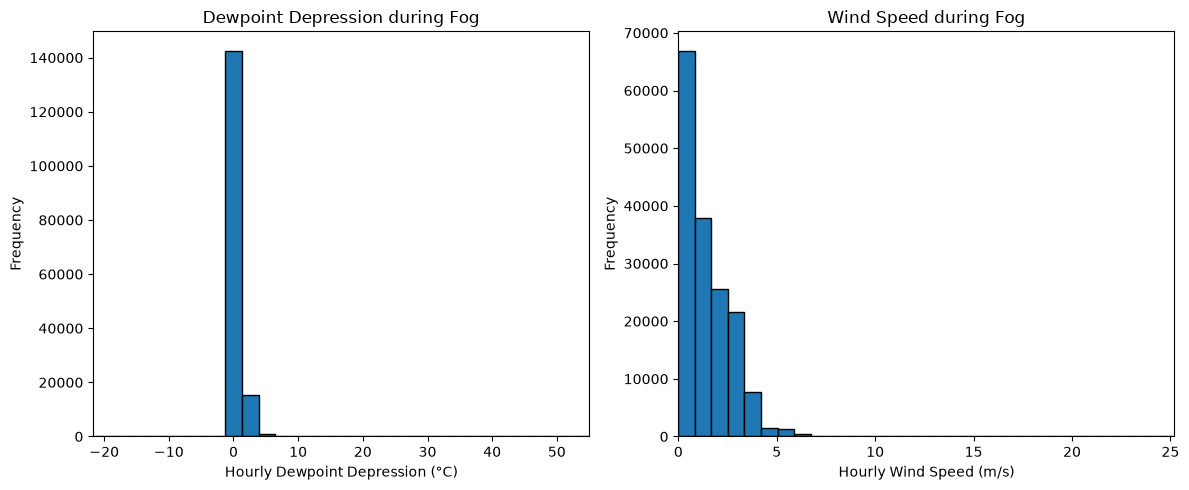

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Hourly Dewpoint Depression
axes[0].hist(CV_fog_rows['HourlyDewpointDepression'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Dewpoint Depression during Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[0].set_xlim(CV_fog_rows['HourlyDewpointDepression'].min(), CV_fog_rows['HourlyDewpointDepression'].max())

# Histogram for Hourly Wind Speed
axes[1].hist(CV_fog_rows['HourlyWindSpeed'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Wind Speed during Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[1].set_xlim(CV_fog_rows['HourlyWindSpeed'].min(), CV_fog_rows['HourlyWindSpeed'].max())

plt.tight_layout()
plt.show()

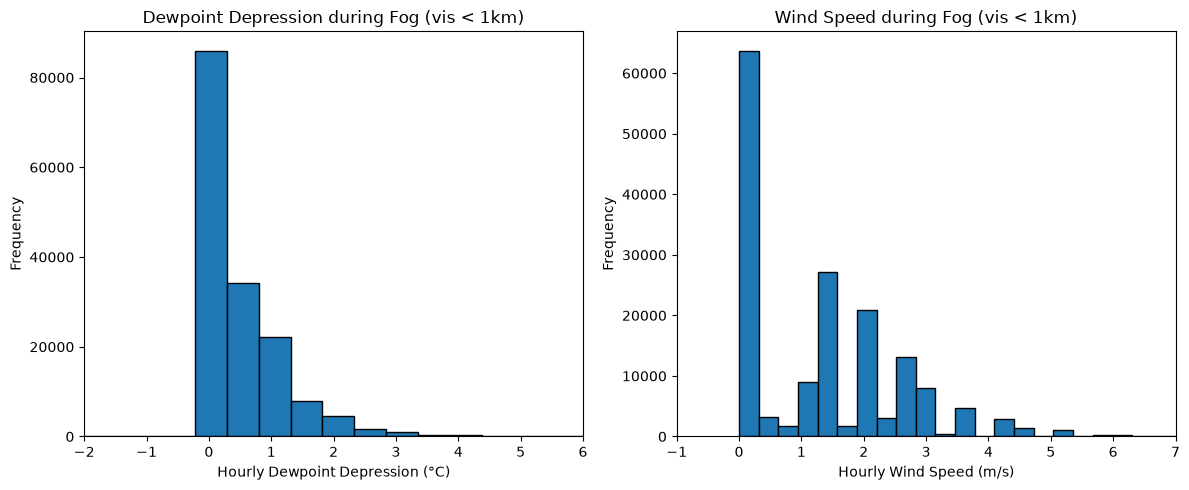

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    CV_fog_rows['HourlyDewpointDepression'].dropna(),
    bins=150,
    edgecolor='black'
)
axes[0].set_title('Dewpoint Depression during Fog (vis < 1km)')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-2, 6)

axes[1].hist(
    CV_fog_rows['HourlyWindSpeed'].dropna(),
    bins=80,
    edgecolor='black'
)
axes[1].set_title('Wind Speed during Fog (vis < 1km)')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-1, 7)

plt.tight_layout()
plt.show()

In [17]:
# Percentage of fog rows with dewpoint depression between -1 and 4 °C
# and wind speed below 5 m/s
matching_rows = CV_fog_rows[
    CV_fog_rows['HourlyDewpointDepression'].between(-1, 3.5, inclusive='both')
    & (CV_fog_rows['HourlyWindSpeed'] < 5)
]

percentage = 100 * len(matching_rows) / len(CV_fog_rows)

print(f"Matching fog rows: {len(matching_rows):,}")
print(f"Percentage of fog rows: {percentage:.2f}%")

Matching fog rows: 156,062
Percentage of fog rows: 95.60%


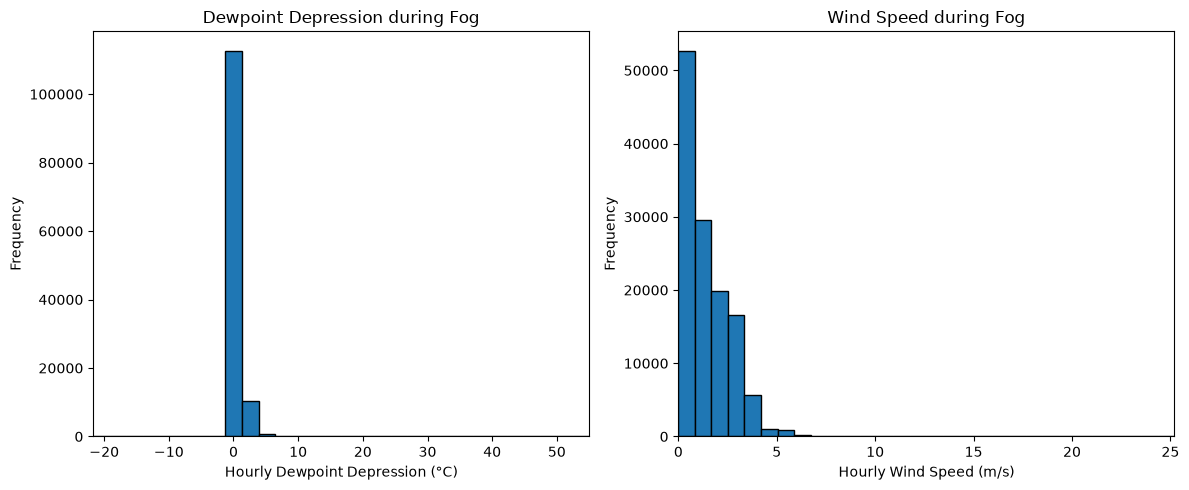

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Hourly Dewpoint Depression
axes[0].hist(CV_heavy_fog_rows['HourlyDewpointDepression'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Dewpoint Depression during Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[0].set_xlim(CV_heavy_fog_rows['HourlyDewpointDepression'].min(), CV_heavy_fog_rows['HourlyDewpointDepression'].max())

# Histogram for Hourly Wind Speed
axes[1].hist(CV_heavy_fog_rows['HourlyWindSpeed'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Wind Speed during Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[1].set_xlim(CV_heavy_fog_rows['HourlyWindSpeed'].min(), CV_heavy_fog_rows['HourlyWindSpeed'].max())

plt.tight_layout()
plt.show()

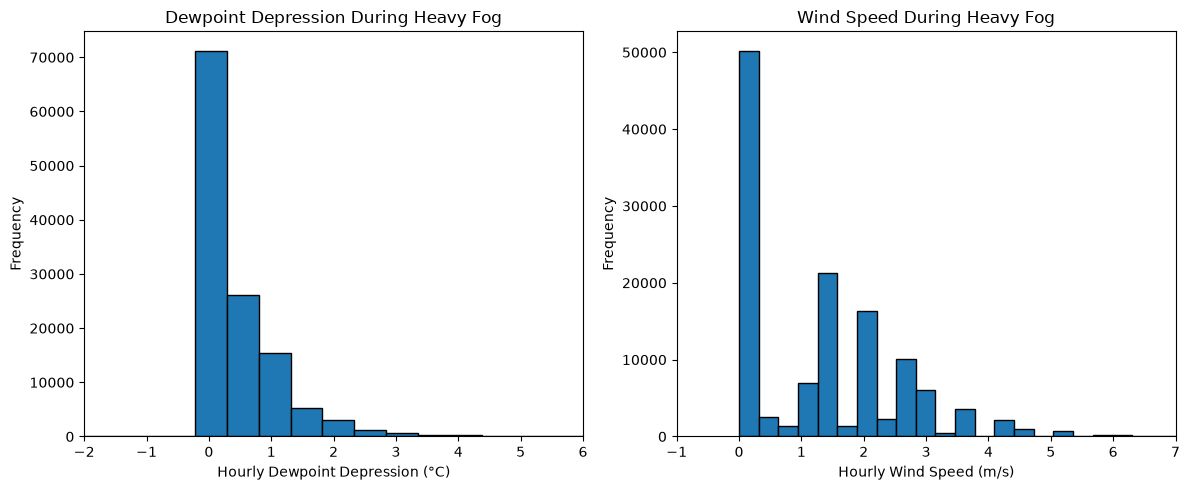

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    CV_heavy_fog_rows['HourlyDewpointDepression'].dropna(),
    bins=150,
    edgecolor='black'
)
axes[0].set_title('Dewpoint Depression During Heavy Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-2, 6)

axes[1].hist(
    CV_heavy_fog_rows['HourlyWindSpeed'].dropna(),
    bins=80,
    edgecolor='black'
)
axes[1].set_title('Wind Speed During Heavy Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-1, 7)

plt.tight_layout()
plt.show()

In [16]:
# Percentage of fog rows with dewpoint depression between -1 and 4 °C
# and wind speed below 5 m/s
matching_rows_h = CV_heavy_fog_rows[
    CV_heavy_fog_rows['HourlyDewpointDepression'].between(-1, 3.5, inclusive='both')
    & (CV_heavy_fog_rows['HourlyWindSpeed'] < 5)
]

percentage = 100 * len(matching_rows_h) / len(CV_heavy_fog_rows)

print(f"Matching fog rows: {len(matching_rows_h):,}")
print(f"Percentage of fog rows: {percentage:.2f}%")

Matching fog rows: 121,744
Percentage of fog rows: 95.95%
